<a href="https://colab.research.google.com/github/Antonius74/colab_algo_experiments/blob/main/SVM_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

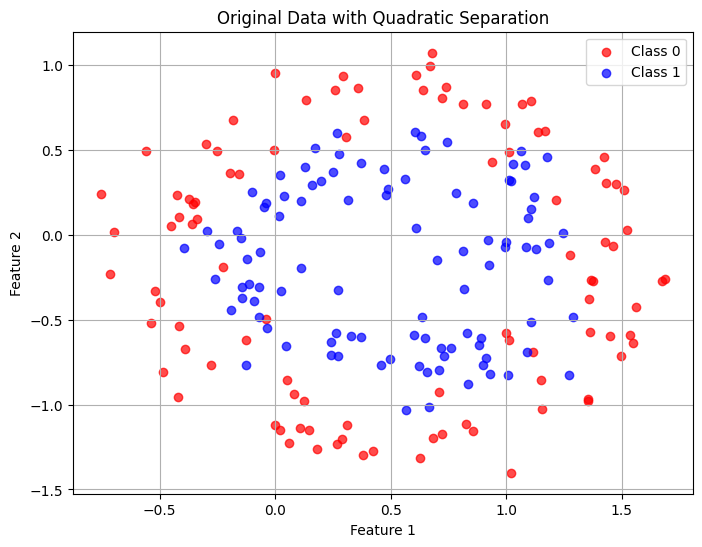

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

# Generate a dataset that is not linearly separable, but quadratically separable
X, y = make_circles(n_samples=200, factor=.6, noise=.15, random_state=42)

# Add an offset to make it clearly quadratic
X[:, 0] = X[:, 0] + 0.5
X[:, 1] = X[:, 1] - 0.2

plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', label='Class 0', alpha=0.7)
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Class 1', alpha=0.7)
plt.title('Original Data with Quadratic Separation')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

As you can see from the plot above, the two classes are not linearly separable. You cannot draw a single straight line to perfectly separate them. However, they are clearly separable by a circle (a quadratic boundary).

Now, let's explore how we can transform this data to make it linearly separable. This is where the 'kernel trick' comes into play, specifically by explicitly creating polynomial features.

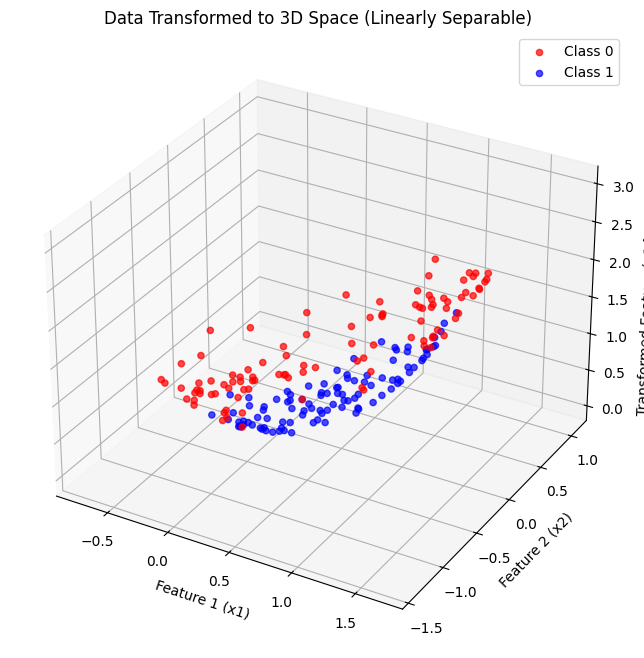

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features up to degree 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# X_poly now contains features: [x1, x2, x1^2, x1*x2, x2^2]
# For visualization purposes, let's pick 3 key features for a 3D plot
# We can choose x1, x2, and a combination like x1^2 + x2^2 or a single polynomial feature

# Let's use x1, x2, and a combination that highlights the quadratic nature (e.g., x1^2 + x2^2)
# Or more directly, we can use the original x1, x2 and one of the polynomial features like x1^2 or x2^2
# For better visualization of linear separability in 3D, let's use the original x1, x2 and the radial feature (x1^2 + x2^2) or a similar combination from X_poly.

# Based on the structure of make_circles, the radial distance from the origin is key.
# X_poly contains columns like x1, x2, x1^2, x1*x2, x2^2
# The radial feature is essentially related to x1^2 + x2^2

# Let's extract the relevant features for a 3D plot:
# Feature 1: Original X[:, 0]
# Feature 2: Original X[:, 1]
# Feature 3: A combination of polynomial features that highlights separation, e.g., x1^2 + x2^2
# Looking at the output of PolynomialFeatures for 2 features:
# [x1, x2, x1^2, x1x2, x2^2]
# Let's choose original x1, original x2, and x1^2 + x2^2 as the third dimension for visualization

# Calculate x1^2 + x2^2 as a new feature
X_transformed_3d = np.c_[X, X[:, 0]**2 + X[:, 1]**2]

# Plotting in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_transformed_3d[y == 0, 0], X_transformed_3d[y == 0, 1], X_transformed_3d[y == 0, 2], color='red', label='Class 0', alpha=0.7)
ax.scatter(X_transformed_3d[y == 1, 0], X_transformed_3d[y == 1, 1], X_transformed_3d[y == 1, 2], color='blue', label='Class 1', alpha=0.7)

ax.set_title('Data Transformed to 3D Space (Linearly Separable)')
ax.set_xlabel('Feature 1 (x1)')
ax.set_ylabel('Feature 2 (x2)')
ax.set_zlabel('Transformed Feature (x1^2 + x2^2)')
ax.legend()
plt.show()

Come puoi vedere dal grafico 3D, i dati ora sono linearmente separabili! Possiamo immaginare un piano che separa le due classi in questo spazio a 3 dimensioni. Questo piano nel 3D corrisponde alla curva quadratica che abbiamo visto nel grafico 2D originale.

Questo è il principio fondamentale del 'kernel trick': trasformare implicitamente o esplicitamente i dati in uno spazio dimensionale superiore dove le classi diventano linearmente separabili, anche se non lo erano nello spazio originale.

In [ ]:
from sklearn.svm import LinearSVC

# Train a Linear SVM in the transformed 3D space
# C is the regularization parameter. Smaller C promotes wider margins (more regularization).
# For demonstration, we'll pick a value that gives a good separation.
svm = LinearSVC(C=1.0, random_state=42, dual=False)
svm.fit(X_transformed_3d, y)

# Get the coefficients and intercept of the separating hyperplane
coef = svm.coef_[0]
intercept = svm.intercept_[0]

print(f"Coefficienti del piano (w): {coef}")
print(f"Intercetta del piano (b): {intercept}")

Coefficienti del piano (w): [ 2.63265302 -0.86178635 -2.57078458]
Intercetta del piano (b): 1.0577035355730984


Abbiamo addestrato un SVM lineare nello spazio 3D. Ora che abbiamo i coefficienti e l'intercetta del piano di separazione, possiamo visualizzarlo nello spazio 3D.

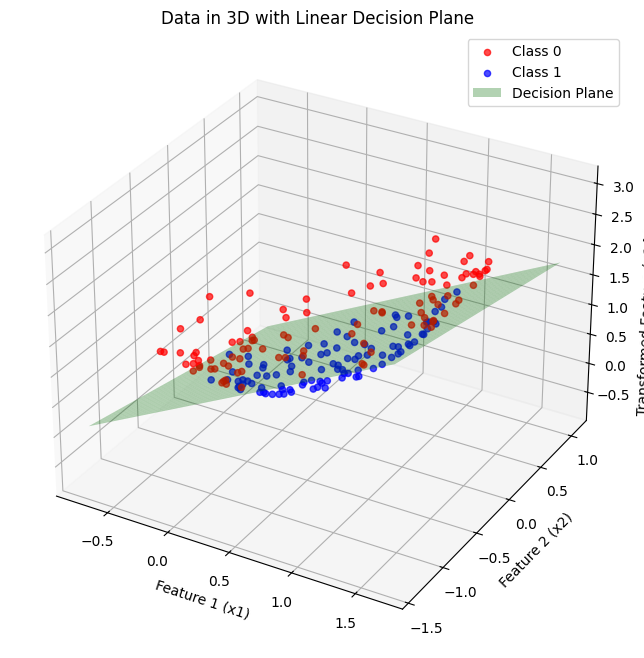

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the data points
ax.scatter(X_transformed_3d[y == 0, 0], X_transformed_3d[y == 0, 1], X_transformed_3d[y == 0, 2], color='red', label='Class 0', alpha=0.7)
ax.scatter(X_transformed_3d[y == 1, 0], X_transformed_3d[y == 1, 1], X_transformed_3d[y == 1, 2], color='blue', label='Class 1', alpha=0.7)

# Create a meshgrid for the plane
x1_surf, x2_surf = np.meshgrid(np.linspace(X_transformed_3d[:, 0].min(), X_transformed_3d[:, 0].max(), 100),
                               np.linspace(X_transformed_3d[:, 1].min(), X_transformed_3d[:, 1].max(), 100))

# Equation of the plane: w0*x1 + w1*x2 + w2*(x1^2 + x2^2) + b = 0
# Solving for z (which is x1^2 + x2^2): z = -(w0*x1 + w1*x2 + b) / w2
# Be careful with division by zero if w2 is near zero, though unlikely in this case
if coef[2] != 0:
    z_surf = -(coef[0] * x1_surf + coef[1] * x2_surf + intercept) / coef[2]
else:
    # Handle case where coef[2] is zero (unlikely for quadratic separation)
    z_surf = np.zeros_like(x1_surf) # or some other appropriate handling

# Plot the decision plane
ax.plot_surface(x1_surf, x2_surf, z_surf, alpha=0.3, color='green', label='Decision Plane')

ax.set_title('Data in 3D with Linear Decision Plane')
ax.set_xlabel('Feature 1 (x1)')
ax.set_ylabel('Feature 2 (x2)')
ax.set_zlabel('Transformed Feature (x1^2 + x2^2)')
ax.legend()
plt.show()

Ora, la parte magica: proiettiamo questo piano di decisione lineare *indietro* nello spazio 2D originale. Il piano nello spazio 3D si traduce in una curva quadratica nello spazio 2D, dimostrando come l'SVM ha trovato una separazione non lineare nel dominio originale.

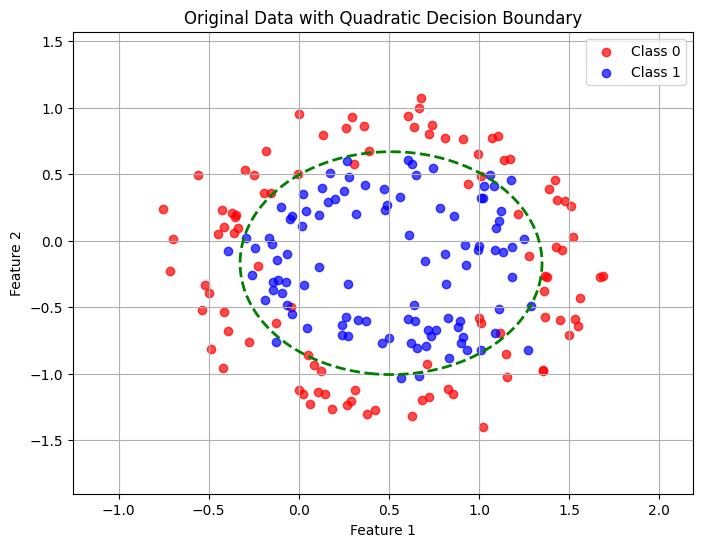

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', label='Class 0', alpha=0.7)
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Class 1', alpha=0.7)

# To plot the 2D decision boundary, we need to set the 3D plane equation to 0:
# w0*x1 + w1*x2 + w2*(x1^2 + x2^2) + b = 0
# This is a quadratic equation in x1 and x2. We can't easily plot it as a simple function.
# Instead, we'll create a fine grid of points in the original 2D space
# and evaluate the decision function of the SVM for each point.

# Define bounds for the plot
x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

# Create a meshgrid for plotting the decision boundary
xx, yy = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                     np.linspace(x2_min, x2_max, 200))

# Transform the meshgrid points into the 3D space using the same transformation
xy_grid = np.c_[xx.ravel(), yy.ravel()]
xy_grid_transformed = np.c_[xy_grid, xy_grid[:, 0]**2 + xy_grid[:, 1]**2]

# Get the decision function output for each point in the grid
Z = svm.decision_function(xy_grid_transformed).reshape(xx.shape)

# Plot the decision boundary (where Z = 0)
plt.contour(xx, yy, Z, levels=[0], colors='green', linewidths=2, linestyles='dashed')

plt.title('Original Data with Quadratic Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

### 1. Spiegazione Intuitiva

Immagina di avere due gruppi di punti di diversi colori su un tavolo e vuoi disegnarci una linea per dividerli. L'**SVM (Support Vector Machine)** è come un algoritmo che trova la *migliore* linea possibile per separarli, quella che massimizza lo spazio (il 'margine') tra la linea e i punti più vicini di entrambi i gruppi (questi punti sono chiamati 'support vector').

Ma cosa succede se i punti non sono separabili da una linea retta? Immagina che i punti rossi siano al centro e quelli blu all'esterno, come un bersaglio. Una linea retta non può separarli. Qui entra in gioco il **Kernel Trick**:

È come se sollevassimo il tavolo (i nostri dati) e lo guardassimo da una prospettiva diversa. Se i punti blu fossero più in alto dei punti rossi, ora potremmo usare un piano (come una lastra di vetro) per separarli. Il Kernel Trick fa proprio questo: prende i tuoi dati e li proietta in una dimensione superiore dove diventano separabili da una linea (o un piano, o un iperpiano, a seconda delle dimensioni).

### 2. Spiegazione con un Esempio (quello che abbiamo appena fatto!)

Ripensiamo all'esempio che abbiamo appena visto:

1.  **Dati Originali (2D):** Abbiamo iniziato con due classi di punti (rossi e blu) in un piano 2D. Erano disposti a cerchi concentrici, rendendo impossibile tracciare una singola linea retta per separarli. Questa era una **separazione quadratica**.

2.  **Trasformazione nello Spazio 3D (il Kernel Trick):** Abbiamo applicato una trasformazione aggiungendo una nuova dimensione che era la somma dei quadrati delle due dimensioni originali (x1² + x2²). Questo ha l'effetto di 'sollevare' i punti che sono più distanti dall'origine nello spazio 3D.
    *   **Risultato:** Nello spazio 3D, i punti delle due classi sono diventati linearmente separabili! Improvvisamente, è stato possibile trovare un *piano* che dividesse perfettamente i punti rossi dai punti blu.

3.  **Il Classificatore Lineare in 3D:** Abbiamo poi addestrato un SVM lineare (o `LinearSVC`) in questo spazio 3D. Questo SVM ha trovato l'equazione di quel piano di separazione.

4.  **Riproiezione nello Spazio 2D:** Quando riproiettiamo questo piano di decisione 3D nello spazio 2D originale, esso non apparirà più come un piano, ma come la *curva quadratica* (il cerchio) che separa le due classi. Questo dimostra che l'SVM, pur lavorando con un concetto lineare (un piano) in uno spazio trasformato, riesce a trovare un confine di decisione non lineare nel dominio originale.

Il *kernel trick* è 'trick' perché spesso non calcoliamo esplicitamente tutte le nuove coordinate nello spazio ad alta dimensione (cosa che può essere molto costosa computazionalmente), ma usiamo una funzione kernel che ci permette di calcolare il 'prodotto scalare' tra vettori in quello spazio ad alta dimensione, *senza mai doverlo effettivamente costruire*.

### 3. Spiegazione Matematica

L'obiettivo di un SVM è trovare un iperpiano che massimizzi il margine tra le classi. Matematicamente, l'iperpiano è definito da $w \cdot x + b = 0$, dove $w$ è il vettore dei pesi (normale all'iperpiano) e $b$ è il termine di bias.

Il problema di ottimizzazione per un SVM lineare è:

Minimize: $\frac{1}{2} \|w\|^2$
Subject to: $y_i(w \cdot x_i + b) \ge 1$ for all $i$

Dove $x_i$ sono i vettori dei dati e $y_i$ sono le loro etichette di classe (-1 o 1).

Quando i dati non sono linearmente separabili nello spazio originale $\mathcal{X}$, li trasformiamo in uno spazio a dimensioni superiori $\mathcal{F}$ tramite una funzione di mappatura $\phi: \mathcal{X} \to \mathcal{F}$. Nello spazio $\mathcal{F}$, i dati possono essere linearmente separabili. Il problema di ottimizzazione diventa:

Minimize: $\frac{1}{2} \|w\|^2$
Subject to: $y_i(w \cdot \phi(x_i) + b) \ge 1$ for all $i$

La magia del **kernel trick** sta nel fatto che il vettore dei pesi $w$ può essere espresso come una combinazione lineare dei vettori di supporto: $w = \sum_{j} \alpha_j y_j \phi(x_j)$. Sostituendo questo nell'equazione dell'iperpiano e nel problema di ottimizzazione duale, si scopre che le uniche operazioni necessarie con $\phi(x_i)$ sono i prodotti scalari della forma $\phi(x_i) \cdot \phi(x_j)$.

Il **Kernel Function**, $K(x_i, x_j) = \phi(x_i) \cdot \phi(x_j)$, ci permette di calcolare questo prodotto scalare *direttamente* nello spazio originale, senza dover calcolare esplicitamente $\phi(x_i)$ o $\phi(x_j)$ e senza dover effettivamente mappare i dati in $\mathcal{F}$.

Nel nostro esempio, il kernel trick è stato applicato usando una mappatura polinomiale di grado 2. Per due feature $x_1, x_2$, una mappatura $\phi(x_1, x_2)$ potrebbe essere verso uno spazio 3D dove una delle dimensioni è $x_1^2 + x_2^2$. Il kernel polinomiale di grado 2, ad esempio, è $K(x, z) = (x \cdot z + c)^2$. Questo ci permette di operare efficacemente nello spazio trasformato per trovare un confine non lineare nel dominio originale.